In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('analyzed_customer_feedback.csv')
df.head()

,id,channel,message,timestamp,intent,urgency,cluster
0,1,email,App update installed smoothly.,2025-03-29 06:32:05,suggestion,medium,1
1,2,social_media,Add a live chat support option.,2025-03-24 14:28:33,suggestion,low,3
2,3,email,Customer service is not responding to my emails.,2025-03-24 13:25:46,complaint,high,-1
3,4,website_form,Please add more payment options.,2025-03-29 10:17:49,suggestion,low,4
4,5,social_media,The delivery was delayed by more than a week.,2025-03-24 06:28:02,complaint,high,5


C:\Users\sagarikak\AppData\Local\Temp\ipykernel_10908\2786584354.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster', data=df, palette='Set2', order=sorted(df['cluster'].unique()),legend=False)


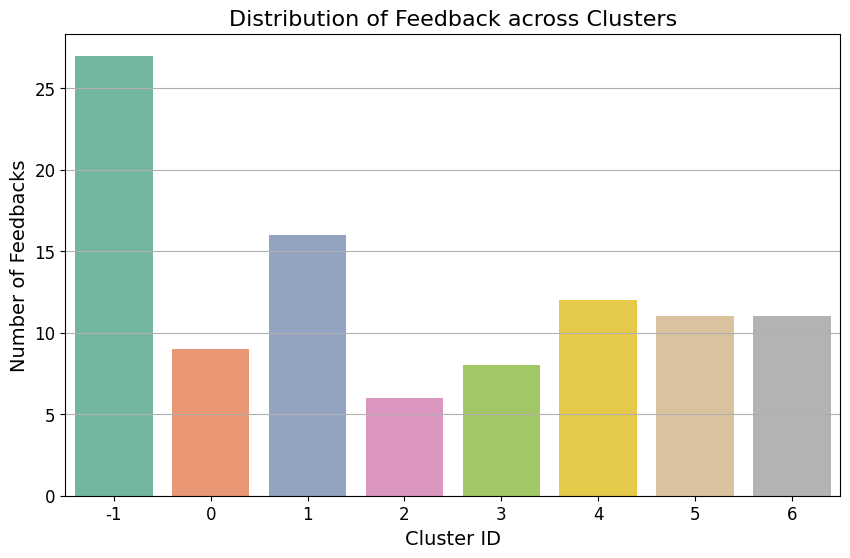

In [3]:
plt.figure(figsize=(10,6))
sns.countplot(x='cluster', data=df, palette='Set2', order=sorted(df['cluster'].unique()),legend=False)
plt.title('Distribution of Feedback across Clusters', fontsize=16)
plt.xlabel('Cluster ID', fontsize=14)
plt.ylabel('Number of Feedbacks', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y')
plt.show()

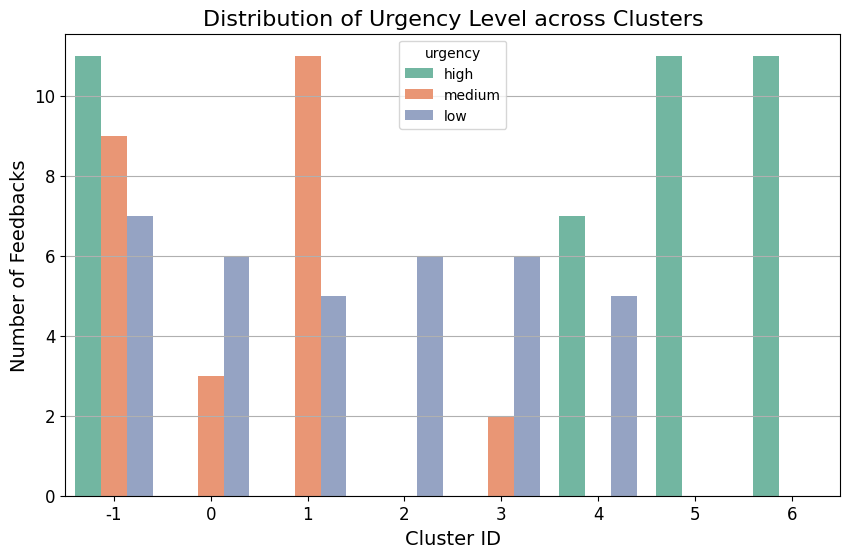

In [4]:
plt.figure(figsize=(10,6))
sns.countplot(df, x='cluster', hue="urgency",palette='Set2')
plt.title('Distribution of Urgency Level across Clusters', fontsize=16)
plt.xlabel('Cluster ID', fontsize=14)
plt.ylabel('Number of Feedbacks', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y')
plt.show()

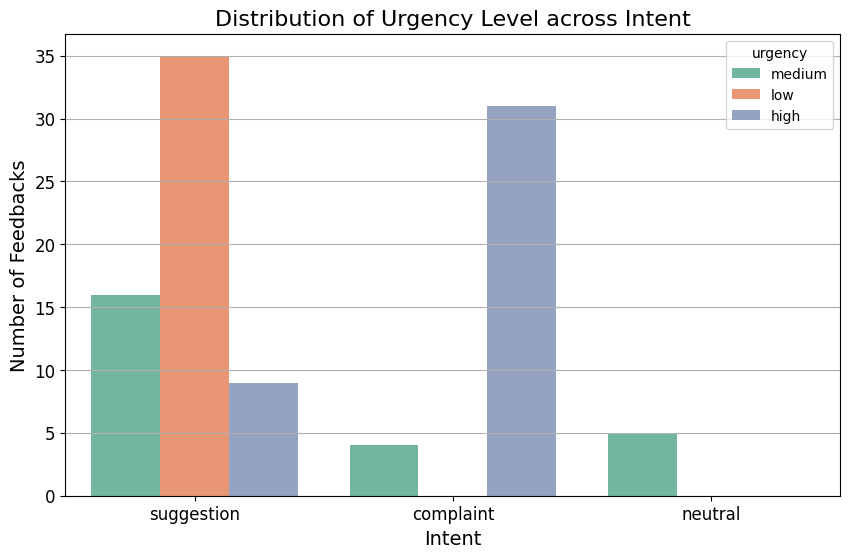

In [5]:
plt.figure(figsize=(10,6))
sns.countplot(df, x='intent', hue="urgency",palette='Set2')
plt.title('Distribution of Urgency Level across Intent', fontsize=16)
plt.xlabel('Intent', fontsize=14)
plt.ylabel('Number of Feedbacks', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y')
plt.show()

In [6]:
df['channel'].unique()

array(['email', 'social_media', 'website_form'], dtype=object)

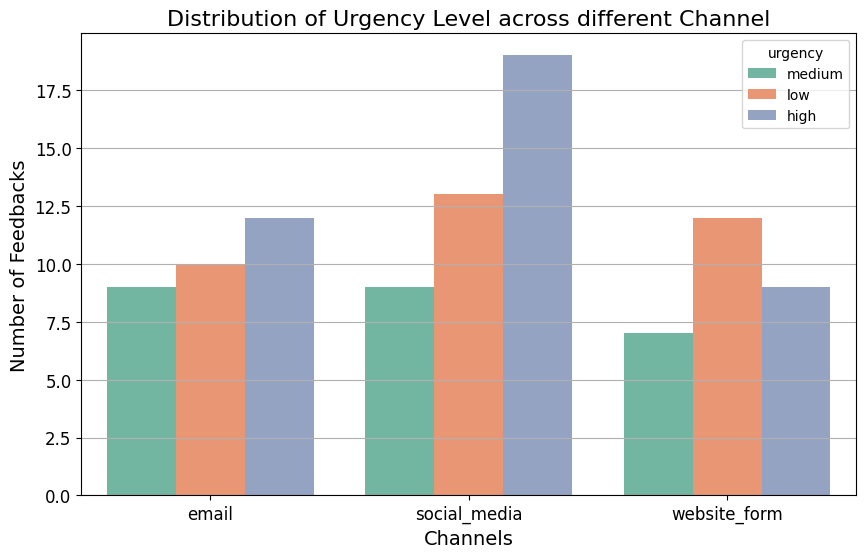

In [7]:
plt.figure(figsize=(10,6))
sns.countplot(df, x='channel', hue="urgency",palette='Set2')
plt.title('Distribution of Urgency Level across different Channel', fontsize=16)
plt.xlabel('Channels', fontsize=14)
plt.ylabel('Number of Feedbacks', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y')
plt.show()

In [8]:
df[df['cluster']==1]

,id,channel,message,timestamp,intent,urgency,cluster
0,1,email,App update installed smoothly.,2025-03-29 06:32:05,suggestion,medium,1
7,8,email,The app crashes every time I open it.,2025-03-29 08:58:52,complaint,medium,1
12,13,social_media,App update installed smoothly.,2025-03-20 11:18:26,suggestion,medium,1
19,20,website_form,Introduce dark mode in the app.,2025-04-03 14:14:17,suggestion,low,1
31,32,email,App update installed smoothly.,2025-04-03 10:14:43,suggestion,medium,1
41,42,email,Introduce dark mode in the app.,2025-03-20 12:32:49,suggestion,low,1
46,47,social_media,Introduce dark mode in the app.,2025-04-01 01:40:45,suggestion,low,1
55,56,social_media,App update installed smoothly.,2025-04-16 11:24:13,suggestion,medium,1
57,58,social_media,App UI looks clean and user-friendly.,2025-04-14 20:39:30,suggestion,medium,1
59,60,website_form,App UI looks clean and user-friendly.,2025-03-20 03:00:35,suggestion,medium,1


In [9]:
# high priority complaints
high_priority_complaints = df[(df['intent'] == 'complaint') & (df['urgency'] == 'high')]
high_priority_complaints.head()

,id,channel,message,timestamp,intent,urgency,cluster
2,3,email,Customer service is not responding to my emails.,2025-03-24 13:25:46,complaint,high,-1
4,5,social_media,The delivery was delayed by more than a week.,2025-03-24 06:28:02,complaint,high,5
6,7,website_form,My payment failed while checking out.,2025-04-01 01:30:07,complaint,high,4
13,14,social_media,My payment failed while checking out.,2025-04-10 18:35:47,complaint,high,4
14,15,social_media,I have not received my order yet.,2025-03-31 11:09:49,complaint,high,6


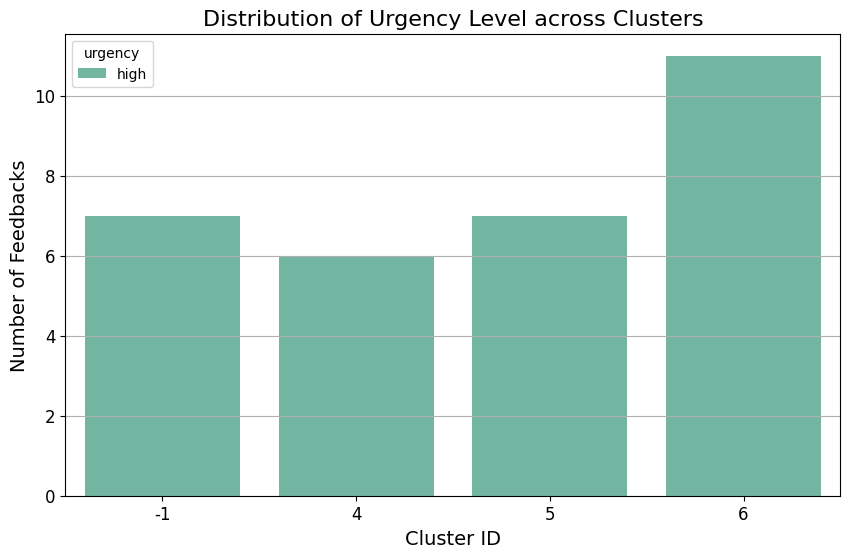

In [10]:
plt.figure(figsize=(10,6))
sns.countplot(high_priority_complaints, x='cluster', hue="urgency",palette='Set2')
plt.title('Distribution of Urgency Level across Clusters', fontsize=16)
plt.xlabel('Cluster ID', fontsize=14)
plt.ylabel('Number of Feedbacks', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y')
plt.show()

In [11]:
medium_priority_complaints = df[(df['intent'] == 'complaint') & (df['urgency'] == 'medium')]
medium_priority_complaints.shape

(4, 7)

In [12]:
medium_priority_complaints

,id,channel,message,timestamp,intent,urgency,cluster
7,8,email,The app crashes every time I open it.,2025-03-29 08:58:52,complaint,medium,1
21,22,website_form,There was an error during the signup process.,2025-04-10 04:21:44,complaint,medium,3
33,34,email,There was an error during the signup process.,2025-03-27 11:08:16,complaint,medium,3
85,86,social_media,The app crashes every time I open it.,2025-04-09 11:06:18,complaint,medium,1


In [13]:
df[df['cluster']==-1]

,id,channel,message,timestamp,intent,urgency,cluster
2,3,email,Customer service is not responding to my emails.,2025-03-24 13:25:46,complaint,high,-1
8,9,social_media,Thanks for the quick support.,2025-04-07 11:39:51,suggestion,medium,-1
9,10,website_form,Your website is very easy to navigate.,2025-04-14 07:23:17,neutral,medium,-1
20,21,website_form,Can you provide a loyalty rewards program?,2025-04-09 08:25:51,suggestion,low,-1
24,25,website_form,Refund process is taking too long.,2025-04-12 08:24:41,complaint,high,-1
30,31,social_media,It would be great to have offline access.,2025-04-07 03:46:00,suggestion,low,-1
32,33,email,It would be great to have offline access.,2025-03-22 01:34:29,suggestion,low,-1
40,41,website_form,It would be great to have offline access.,2025-04-01 09:26:07,suggestion,low,-1
43,44,social_media,Your website is very easy to navigate.,2025-03-29 06:28:27,neutral,medium,-1
48,49,email,Loved the packaging of the product.,2025-04-08 04:13:50,suggestion,high,-1


In [14]:
df[df['cluster']==-1]['message'].unique()

array(['Customer service is not responding to my emails.',
       'Thanks for the quick support.',
       'Your website is very easy to navigate.',
       'Can you provide a loyalty rewards program?',
       'Refund process is taking too long.',
       'It would be great to have offline access.',
       'Loved the packaging of the product.',
       'Please allow login using social accounts.'], dtype=object)

In [15]:
df[df['cluster']==-1]['intent'].value_counts()

intent
suggestion    18
complaint      7
neutral        2
Name: count, dtype: int64